# Comparison of anisotropic fits

This notebook compares the saved `cf_ca_aniso` results without rerunning the scattering fits. It automatically discovers available concentrations, overlays measured and fitted curves, checks fit/data ratios, and summarizes the fitted radial width and anisotropy.

In [16]:
from pathlib import Path
import csv
import re
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Ellipse
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.alpha': 0.22,
})
OUTPUT_DIR = Path('output/ca_aniso')

# Keep these switches identical to the settings used in cf_ca_aniso.ipynb.
K_DISTRIBUTION = 'gamma_radial'  # 'gaussian_radial' or 'gamma_radial'
STRETCH_MODEL = 'full_geom'  # 'spectrum' or 'full_geom'
DISTRIBUTION_UPPER_QUANTILE = 0.99999  # extend P(k) until the upper tail is visually negligible
# ELLIPSE_COUNT = 7
# ELLIPSE_LAMBDA_ENDPOINTS = (1.0, 2.5)
CHI_SQUARE_ERROR_FLOOR = 0.04
FALLBACK_FITTED_PARAMETER_COUNT = 4  # scale, k_eff, r_sigma_k, stretch_ratio
LINEARIZED_BOOTSTRAP_ENABLED = True
LINEARIZED_BOOTSTRAP_SAMPLES = 1000
LINEARIZED_BOOTSTRAP_LOG_STEP = 0.01
LINEARIZED_BOOTSTRAP_SEED = 20260806
BOOTSTRAP_HIGHQ_ANCHOR_WEIGHT = 1.0
BOOTSTRAP_LINE_DENSITY_CONSTRAINT = {
    'enabled': False,
    'reference_density': 2.998586541845732e-4,
    'relative_sigma': 0.05,
    'penalty_mode': 'below_reference_only',
}
if K_DISTRIBUTION not in {'gaussian_radial', 'gamma_radial'}:
    raise ValueError('K_DISTRIBUTION must be gaussian_radial or gamma_radial')
if STRETCH_MODEL not in {'spectrum', 'full_geom'}:
    raise ValueError('STRETCH_MODEL must be spectrum or full_geom')
# if int(ELLIPSE_COUNT) < 1:
#     raise ValueError('ELLIPSE_COUNT must be at least 1')
# if len(ELLIPSE_LAMBDA_ENDPOINTS) != 2 or not (0 < ELLIPSE_LAMBDA_ENDPOINTS[0] < ELLIPSE_LAMBDA_ENDPOINTS[1]):
#     raise ValueError('ELLIPSE_LAMBDA_ENDPOINTS must be two increasing positive values')

FIT_GUIDANCE_TAG = f'unguided_{K_DISTRIBUTION}_{STRETCH_MODEL}_OH2'
PARAMETER_SUFFIX = f'_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv'
CURVE_SUFFIX = f'_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_curve.csv'
COMPARE_TAG = f'{K_DISTRIBUTION}_{STRETCH_MODEL}'
COMPARE_OUTPUT_DIR = OUTPUT_DIR / 'comparison' / COMPARE_TAG
COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'[comparison mode] k_distribution={K_DISTRIBUTION}, stretch={STRETCH_MODEL}')


[comparison mode] k_distribution=gamma_radial, stretch=full_geom


In [9]:
def concentration_from_tag(tag):
    if tag == 'ca_D2O':
        return 0.0
    match = re.fullmatch(r'ca_(\d+(?:\.\d+)?)mM', tag)
    if match is None:
        raise ValueError(f'Cannot parse concentration from {tag!r}')
    return float(match.group(1))

def load_parameter_csv(path):
    with path.open(newline='', encoding='utf-8') as handle:
        return {row['name']: float(row['value']) for row in csv.DictReader(handle)}

candidates = []
for parameter_path in OUTPUT_DIR.glob(f'ca_*{PARAMETER_SUFFIX}'):
    tag = parameter_path.name[:-len(PARAMETER_SUFFIX)]
    curve_path = OUTPUT_DIR / f'{tag}{CURVE_SUFFIX}'
    if not curve_path.exists():
        print(f'[skip] missing curve for {parameter_path.name}')
        continue
    parameters = load_parameter_csv(parameter_path)
    concentration = parameters.get('salt_concentration_mM', concentration_from_tag(tag))
    curve = np.loadtxt(curve_path, delimiter=',', skiprows=1)
    candidates.append({
        'tag': tag, 'concentration_mM': concentration, 'parameters': parameters,
        'curve': curve, 'parameter_path': parameter_path, 'curve_path': curve_path,
        'complete_pair_mtime': min(parameter_path.stat().st_mtime, curve_path.stat().st_mtime),
    })
newest_by_concentration = {}
for candidate in candidates:
    concentration = float(candidate['concentration_mM'])
    previous = newest_by_concentration.get(concentration)
    if previous is None or candidate['complete_pair_mtime'] > previous['complete_pair_mtime']:
        newest_by_concentration[concentration] = candidate
results = sorted(newest_by_concentration.values(), key=lambda result: result['concentration_mM'])
if not results:
    raise FileNotFoundError(f'No paired fit outputs found in {OUTPUT_DIR}')
print('[loaded]', ', '.join('D2O' if r['concentration_mM'] == 0 else f"{r['concentration_mM']:g} mM" for r in results))
for result in results:
    modified = datetime.fromtimestamp(result['complete_pair_mtime']).isoformat(sep=' ', timespec='seconds')
    print(f"[fit source] {result['parameter_path'].name} | complete pair modified {modified}")


[loaded] D2O, 1 mM, 10 mM, 24 mM, 40 mM, 55 mM, 70 mM, 100 mM
[fit source] ca_0mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 14:59:49
[fit source] ca_1mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:01:35
[fit source] ca_10mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:03:02
[fit source] ca_24mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:05:06
[fit source] ca_40mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:10:18
[fit source] ca_55mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-05 15:12:26
[fit source] ca_70mM_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit_parameters.csv | complete pair modified 2026-08-06 16:19:45
[f

## Fitted values

The wavelength is $2\pi/\langle k\rangle$, `r_sigma_k` is the relative radial width, and `stretch_ratio` is the fitted affine anisotropy.

In [10]:
def incompressible_uniaxial_line_density_factor(stretch_ratio, n_mu=128):
    """Return <|F t|> for isotropic tangents and det(F)=1."""
    stretch_ratio = float(stretch_ratio)
    if not np.isfinite(stretch_ratio) or stretch_ratio <= 0.0:
        raise ValueError('stretch_ratio must be finite and positive')
    mu, weights = np.polynomial.legendre.leggauss(int(n_mu))
    tangent_stretch = np.sqrt(
        stretch_ratio**-1
        + (stretch_ratio**2-stretch_ratio**-1)*mu**2
    )
    return float(0.5*np.dot(weights, tangent_stretch))

summary_rows = []
for result in results:
    p = result['parameters']
    q_curve, observed, error, fitted = result['curve'].T[:4]
    effective_error = np.maximum(error, CHI_SQUARE_ERROR_FLOOR*np.abs(observed))
    data_chi_square = float(np.sum(((fitted-observed)/effective_error)**2))
    n_fitted = int(round(p.get('n_fitted_parameters', FALLBACK_FITTED_PARAMETER_COUNT)))
    degrees_of_freedom = int(observed.size-n_fitted)
    reduced_chi_square = data_chi_square/degrees_of_freedom if degrees_of_freedom > 0 else np.nan
    line_density_before = p['k_eff']**2/(3.0*np.pi)
    fallback_density_factor = incompressible_uniaxial_line_density_factor(p['stretch_ratio'])
    line_density_after = p.get(
        'line_density_geometric',
        line_density_before*fallback_density_factor,
    )
    affine_density_factor = line_density_after/line_density_before
    summary_rows.append({
        'concentration_mM': result['concentration_mM'],
        'k_eff_A^-1': p['k_eff'],
        'mean_k_A^-1': p['mean_k'],
        'wavelength_A': p.get('feature_wavelength_A', 2*np.pi/p['mean_k']),
        'r_sigma_k': p['r_sigma_k'],
        'stretch_ratio': p['stretch_ratio'],
        'line_density_before_A^-2': line_density_before,
        'affine_density_factor': affine_density_factor,
        'line_density_after_A^-2': line_density_after,
        'scale': p.get('scale', np.nan),
        'chi_square_data': data_chi_square,
        'degrees_of_freedom': degrees_of_freedom,
        'reduced_chi_square_data': reduced_chi_square,
    })
columns = tuple(summary_rows[0])
print('  '.join(f'{name:>18s}' for name in columns))
for row in summary_rows:
    print('  '.join(f'{row[name]:18.7g}' for name in columns))
with (COMPARE_OUTPUT_DIR / 'ca_fit_parameter_comparison.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=columns); writer.writeheader(); writer.writerows(summary_rows)


  concentration_mM          k_eff_A^-1         mean_k_A^-1        wavelength_A           r_sigma_k       stretch_ratio  line_density_before_A^-2  affine_density_factor  line_density_after_A^-2               scale     chi_square_data  degrees_of_freedom  reduced_chi_square_data
                 0          0.05241129          0.05173715            119.8823           0.1619569            1.213054        0.0002914598            1.015627        0.0002960144            12.38148            62.88621                 150           0.4192414
                 1          0.05234021          0.05167959            120.0451           0.1604039            1.260462        0.0002906697            1.022654        0.0002972546            12.28619            56.48686                 150           0.3765791
                10          0.04986365          0.04913848            126.0073           0.1724326            1.410754        0.0002638135            1.051444        0.0002773852            12.95518      

## Scattering curves and fit quality

Curves are offset vertically for visibility. The lower panel shows the unshifted fitted-to-observed ratio.

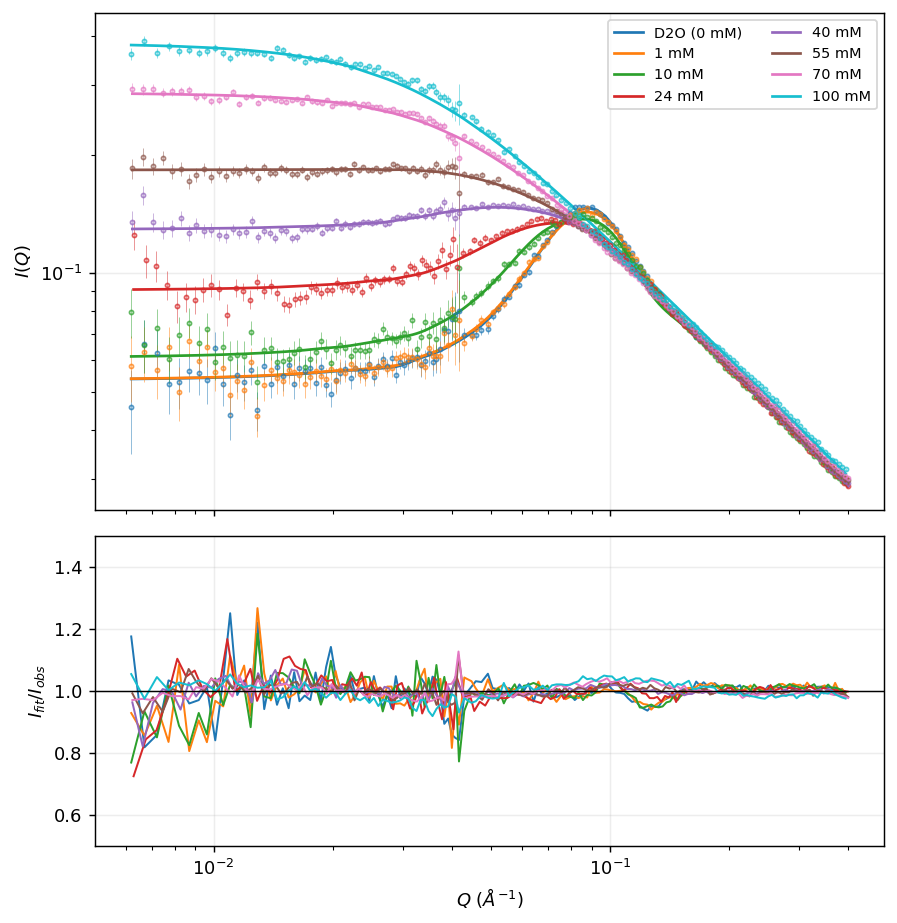

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_fit_curve_comparison.png


In [11]:
DISCRETE_SALT_COLORS = (
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#17becf',  # cyan
)
if len(results) > len(DISCRETE_SALT_COLORS):
    raise ValueError('Add more DISCRETE_SALT_COLORS for the loaded Ca series')
colors = DISCRETE_SALT_COLORS[:len(results)]
fig, axes = plt.subplots(2, 1, figsize=(7.0, 7.2), sharex=True, gridspec_kw={'height_ratios': [1.6, 1.0]})
for index, (result, color) in enumerate(zip(results, colors)):
    q, observed, error, fitted, ratio = result['curve'].T[:5]
    offset = 3.0**index
    offset = 1
    concentration = result['concentration_mM']
    label = 'D2O (0 mM)' if concentration == 0 else f'{concentration:g} mM'
    axes[0].errorbar(q, observed*offset, yerr=error*offset, fmt='o', ms=2.2, lw=0.35, color=color, markerfacecolor='none', alpha=0.75)
    axes[0].plot(q, fitted*offset, color=color, lw=1.5, label=label)
    axes[1].semilogx(q, ratio, color=color, lw=1.1, label=label)
axes[0].set(xscale='log', yscale='log', ylabel=r'$I(Q)$')
axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(1.0, color='black', lw=0.8)
axes[1].set(xlabel=r'$Q$ ($\AA^{-1}$)', ylabel=r'$I_{fit}/I_{obs}$')
axes[1].set_ylim(0.5, 1.5)
fig.tight_layout()
curve_figure = COMPARE_OUTPUT_DIR / 'ca_fit_curve_comparison.png'
fig.savefig(curve_figure, bbox_inches='tight')
plt.show()
print('[saved]', curve_figure)


## Salt dependence of fitted parameters

In [12]:
BOOTSTRAP_PARAMETER_NAMES = ('k_eff', 'r_sigma_k', 'stretch_ratio')
BOOTSTRAP_PARAMETER_BOUNDS = {
    'k_eff': (0.010, 0.50),
    'r_sigma_k': (0.03, 1.20),
    'stretch_ratio': (1.0, 3.0),
}
BOOTSTRAP_MODEL_SETTINGS = {
    'k_distribution': K_DISTRIBUTION, 'k_scale_convention': 'k_eff',
    'regression_loss': 'relative', 'num_modes_k': 2**9, 'k_sampling': 'quadrature',
    'Nr': 2700, 'Nr_small': 600, 'N_samp_U': 2**12, 'N_samp_st': 2**7,
    'NQ': 220, 'r_min_factor': 1e-3, 'r_split_factor': 5.0, 'r_max_factor': 250.0,
    'powder_n_mu': 64,
    'affine_model': 'scalar' if STRETCH_MODEL == 'spectrum' else 'geometric_second_order',
    'N_samp_tangent': 2**12, 'tangent_use_qmc': True, 'tangent_random_seed': 12345,
    'derivative_smoothing_fraction': 1e-2, 'tangent_tail_start_factor': 40.0,
    'tangent_tail_end_factor': 80.0, 'progress': False,
}

def _data_concentration(path):
    name = Path(path).name
    if re.search(r'D2O', name, flags=re.IGNORECASE):
        return 0.0
    match = re.search(r'(\d+(?:\.\d+)?)mM(?:Ca)?IQ', name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'Cannot parse Ca concentration from {name!r}')
    return float(match.group(1))

def _load_four_column_data(path):
    rows = []
    for line in Path(path).read_text(encoding='utf-8', errors='replace').splitlines():
        fields = line.split()
        if len(fields) != 4:
            continue
        try:
            rows.append(tuple(float(value) for value in fields))
        except ValueError:
            continue
    table = np.asarray(rows, dtype=float)
    if table.ndim != 2 or table.shape[0] < 8 or table.shape[1] != 4:
        raise ValueError(f'Could not read Q, I, error, dQ data from {path}')
    return table

def _percentile_interval(samples):
    return tuple(np.percentile(np.asarray(samples, dtype=float), [16.0, 84.0]))

def _linearized_bootstrap_one_fit(result, source_table):
    q_curve, observed, error, fitted = result['curve'].T[:4]
    source_q, source_i, source_error, source_dq = source_table.T
    order = np.argsort(source_q)
    source_q, source_i, source_error, source_dq = (array[order] for array in (source_q, source_i, source_error, source_dq))
    background = float(np.median(np.interp(q_curve, source_q, source_i)-observed))
    working_intensity = source_i-background
    observation = cf.RadialProfile(
        result['tag'], source_q, working_intensity, source_error, np.ones(source_q.size, dtype=int),
    )
    center_values = np.asarray([result['parameters'][name] for name in BOOTSTRAP_PARAMETER_NAMES], dtype=float)
    center_log = np.log(center_values)
    effective_error = np.maximum(error, CHI_SQUARE_ERROR_FLOOR*np.abs(observed))
    standardized_residuals = (observed-fitted)/effective_error
    step = float(LINEARIZED_BOOTSTRAP_LOG_STEP)
    jacobian_columns = []
    log_density_gradient = []
    log_highq_gradient = []

    def evaluate(log_values):
        values = np.exp(log_values)
        parameters = dict(zip(BOOTSTRAP_PARAMETER_NAMES, values))
        evaluated = cf.evaluate_heterogeneous_line_guess(
            observation, q_bounds=(float(q_curve.min()), float(q_curve.max())),
            parameters=parameters, model_mode='line_only', resolution_sigma=source_dq,
            regression_weights=np.ones_like(source_q), model_settings=BOOTSTRAP_MODEL_SETTINGS,
            log_error_floor=CHI_SQUARE_ERROR_FLOOR, regression_loss='relative',
            distribution_parameter_set={'r_sigma_k': {'initial': parameters['r_sigma_k'], 'bounds': (0.03, 1.20)}},
            affine_stretch=True,
        )
        model = np.interp(q_curve, evaluated.q, evaluated.model)
        density = evaluated.parameters['highq_coefficient']/(np.pi*evaluated.parameters['scale'])
        return model, float(density), float(evaluated.parameters['highq_coefficient'])

    for index in range(center_log.size):
        plus = center_log.copy(); plus[index] += step
        minus = center_log.copy(); minus[index] -= step
        model_plus, density_plus, highq_plus = evaluate(plus)
        model_minus, density_minus, highq_minus = evaluate(minus)
        jacobian_columns.append((model_plus-model_minus)/(2.0*step*effective_error))
        log_density_gradient.append((np.log(density_plus)-np.log(density_minus))/(2.0*step))
        log_highq_gradient.append((np.log(highq_plus)-np.log(highq_minus))/(2.0*step))
    data_jacobian = np.column_stack(jacobian_columns)
    log_density_gradient = np.asarray(log_density_gradient)
    fixed_rows = [float(BOOTSTRAP_HIGHQ_ANCHOR_WEIGHT)*np.asarray(log_highq_gradient)]
    density_config = BOOTSTRAP_LINE_DENSITY_CONSTRAINT
    density_center = cf.line_density_from_fit_parameters(result['parameters'])
    if density_config['enabled']:
        mode = str(density_config['penalty_mode'])
        reference = float(density_config['reference_density'])
        if mode == 'two_sided' or (mode == 'below_reference_only' and density_center < reference):
            fixed_rows.append(log_density_gradient/float(density_config['relative_sigma']))
        elif mode != 'below_reference_only':
            raise ValueError('Unknown bootstrap line-density penalty mode')
    bootstrap = cf.linearized_residual_bootstrap(
        BOOTSTRAP_PARAMETER_NAMES, center_log, data_jacobian, standardized_residuals,
        fixed_jacobian_rows=np.vstack(fixed_rows), n_bootstrap=LINEARIZED_BOOTSTRAP_SAMPLES,
        random_seed=LINEARIZED_BOOTSTRAP_SEED+int(round(result['concentration_mM'])),
    )
    log_samples = bootstrap.samples.copy()
    for index, name in enumerate(BOOTSTRAP_PARAMETER_NAMES):
        lower, upper = BOOTSTRAP_PARAMETER_BOUNDS[name]
        log_samples[:, index] = np.clip(log_samples[:, index], np.log(lower), np.log(upper))
    parameter_samples = np.exp(log_samples)
    density_before_samples = parameter_samples[:, 0]**2/(3.0*np.pi)
    density_after_samples = density_center*np.exp(bootstrap.deltas@log_density_gradient)
    intervals = {
        name: _percentile_interval(parameter_samples[:, index])
        for index, name in enumerate(BOOTSTRAP_PARAMETER_NAMES)
    }
    intervals['line_density_before'] = _percentile_interval(density_before_samples)
    intervals['line_density_after'] = _percentile_interval(density_after_samples)
    return {
        'intervals': intervals, 'rank': bootstrap.jacobian_rank,
        'condition': bootstrap.jacobian_condition, 'background': background,
    }

bootstrap_uncertainties = {}
if LINEARIZED_BOOTSTRAP_ENABLED:
    data_files = {}
    for path in Path('data/Ca').glob('*.dat'):
        data_files[_data_concentration(path)] = path
    print('[linearized bootstrap] 16th--84th percentile intervals; no nonlinear refits')
    for result in results:
        concentration_value = float(result['concentration_mM'])
        if concentration_value not in data_files:
            raise FileNotFoundError(f'No source data for {concentration_value:g} mM Ca')
        uncertainty = _linearized_bootstrap_one_fit(result, _load_four_column_data(data_files[concentration_value]))
        bootstrap_uncertainties[concentration_value] = uncertainty
        intervals = uncertainty['intervals']
        print(f"  {concentration_value:g} mM: k_eff={intervals['k_eff']}, "
              f"width={intervals['r_sigma_k']}, stretch={intervals['stretch_ratio']}, "
              f"rank={uncertainty['rank']}, condition={uncertainty['condition']:.3g}")

def _bootstrap_yerr(values, interval_name):
    if not LINEARIZED_BOOTSTRAP_ENABLED:
        return None
    intervals = [bootstrap_uncertainties[float(row['concentration_mM'])]['intervals'][interval_name] for row in summary_rows]
    lower = np.asarray([interval[0] for interval in intervals])
    upper = np.asarray([interval[1] for interval in intervals])
    return np.vstack((np.maximum(values-lower, 0.0), np.maximum(upper-values, 0.0)))


[linearized bootstrap] 16th--84th percentile intervals; no nonlinear refits
  0 mM: k_eff=(np.float64(0.052214785660768495), np.float64(0.05259044810289853)), width=(np.float64(0.15938162656747695), np.float64(0.16463786377274772)), stretch=(np.float64(1.195685759828331), np.float64(1.2293468636704312)), rank=3, condition=8.75
  1 mM: k_eff=(np.float64(0.05216406883166825), np.float64(0.052515555159103645)), width=(np.float64(0.15779482676345957), np.float64(0.1631788414067461)), stretch=(np.float64(1.2431795241716952), np.float64(1.2775609712942644)), rank=3, condition=9.43
  10 mM: k_eff=(np.float64(0.04964588292129163), np.float64(0.05007084653750201)), width=(np.float64(0.16969301996149133), np.float64(0.17526979012490174)), stretch=(np.float64(1.393646806620866), np.float64(1.4268268024863189)), rank=3, condition=7.02
  24 mM: k_eff=(np.float64(0.04909550843700021), np.float64(0.04987746879504468)), width=(np.float64(0.24495230529359174), np.float64(0.2532707856107398)), stretch=(

C:\Users\ccu\AppData\Local\Temp\ipykernel_29248\1321223578.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(fontsize=8)
C:\Users\ccu\AppData\Local\Temp\ipykernel_29248\1321223578.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(fontsize=8)


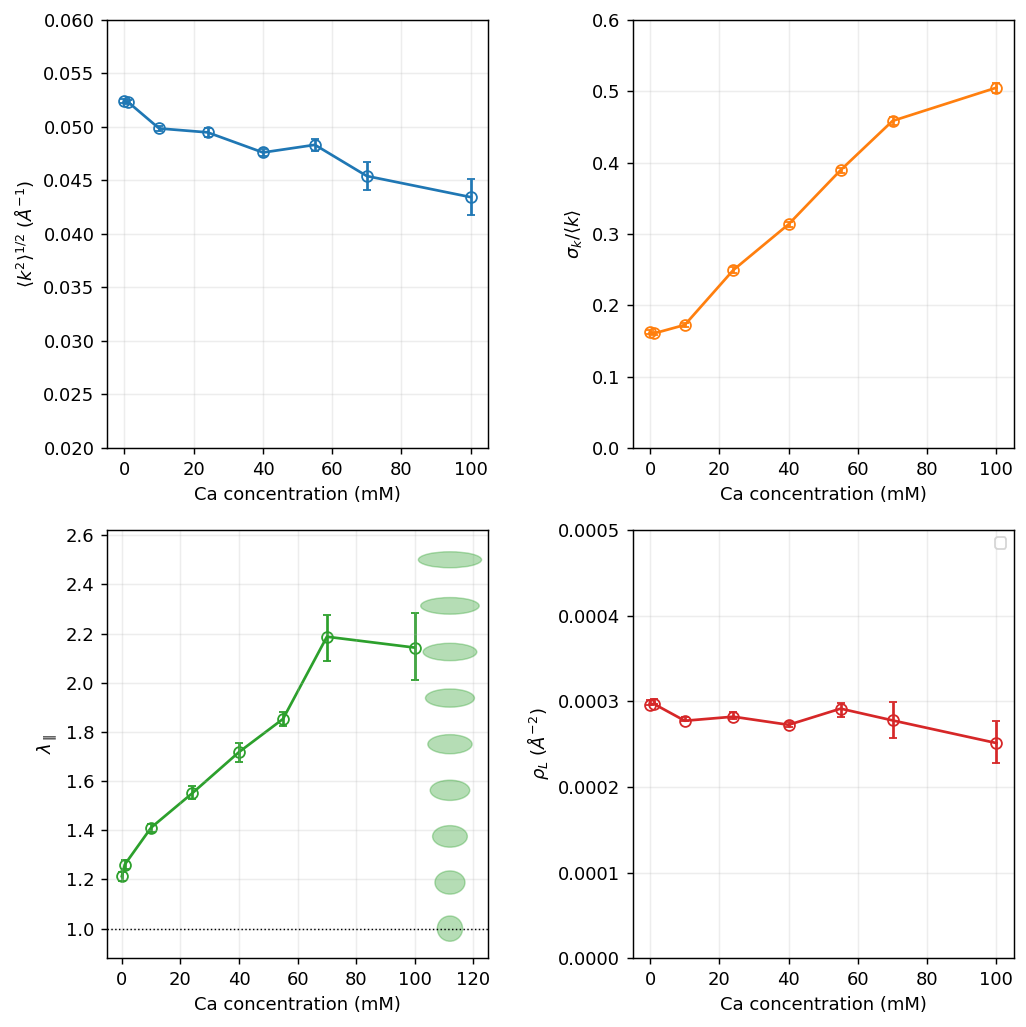

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_fit_parameter_trends.png


In [31]:
concentration = np.asarray([row['concentration_mM'] for row in summary_rows])
k_eff = np.asarray([row['k_eff_A^-1'] for row in summary_rows])
width = np.asarray([row['r_sigma_k'] for row in summary_rows])
line_density_before = np.asarray(
    [row['line_density_before_A^-2'] for row in summary_rows]
)
line_density_after = np.asarray(
    [row['line_density_after_A^-2'] for row in summary_rows]
)
stretch = np.asarray([row['stretch_ratio'] for row in summary_rows])

# Ellipse display settings
ELLIPSE_COUNT = 9
ELLIPSE_LAMBDA_ENDPOINTS = (1.0, 2.5)

fig, axes_arr = plt.subplots(2, 2, figsize=(8, 8))
axes = axes_arr.flatten()

# Panel 1: fitted k_eff
axes[0].errorbar(
    concentration,
    k_eff,
    yerr=_bootstrap_yerr(k_eff, 'k_eff'),
    fmt='o-',
    color='C0',
    markerfacecolor='none',
    capsize=2,
)
axes[0].set(
    xlabel='Ca concentration (mM)',
    ylabel=r'$\langle k^2\rangle^{1/2}$ ($\AA^{-1}$)',
)
axes[0].set_ylim(2e-2, 6e-2)

# Panel 2: fitted distribution width
axes[1].errorbar(
    concentration,
    width,
    yerr=_bootstrap_yerr(width, 'r_sigma_k'),
    fmt='o-',
    color='C1',
    markerfacecolor='none',
    capsize=2,
)
axes[1].set(
    xlabel='Ca concentration (mM)',
    ylabel=r'$\sigma_k/\langle k\rangle$',
)
axes[1].set_ylim(0.0, 0.6)

# Panel 3: fitted stretch
axes[2].errorbar(
    concentration,
    stretch,
    yerr=_bootstrap_yerr(stretch, 'stretch_ratio'),
    fmt='o-',
    color='C2',
    markerfacecolor='none',
    capsize=2,
    zorder=1,
)

ellipse_scale = 14.0
concentration_span = max(float(np.ptp(concentration)), 1.0)
ellipse_x = float(np.max(concentration)) + 0.12 * concentration_span
ellipse_lambda = np.linspace(
    *ELLIPSE_LAMBDA_ENDPOINTS,
    int(ELLIPSE_COUNT),
)

for lambda_parallel in ellipse_lambda:
    lambda_perp = lambda_parallel**(-0.5)
    ellipse_width = ellipse_scale * lambda_parallel
    ellipse_height = ellipse_scale * lambda_perp

    drawing = DrawingArea(ellipse_width, ellipse_height, 0, 0)
    drawing.add_artist(
        Ellipse(
            (0.5 * ellipse_width, 0.5 * ellipse_height),
            width=ellipse_width,
            height=ellipse_height,
            facecolor='C2',
            edgecolor='C2',
            alpha=0.35,
            lw=0.8,
        )
    )
    axes[2].add_artist(
        AnnotationBbox(
            drawing,
            (ellipse_x, lambda_parallel),
            frameon=False,
            pad=0.0,
            box_alignment=(0.5, 0.5),
            zorder=2,
        )
    )

axes[2].axhline(1.0, color='black', lw=0.8, ls=':')
axes[2].set(
    xlabel='Ca concentration (mM)',
    ylabel=r'$\lambda_{\parallel}$',
)
axes[2].set_xlim(
    float(np.min(concentration)) - 0.05 * concentration_span,
    float(np.max(concentration)) + 0.25 * concentration_span,
)

stretch_axis_values = np.concatenate((stretch, ellipse_lambda, [1.0]))
stretch_axis_span = max(float(np.ptp(stretch_axis_values)), 0.1)
axes[2].set_ylim(
    float(np.min(stretch_axis_values)) - 0.08 * stretch_axis_span,
    float(np.max(stretch_axis_values)) + 0.08 * stretch_axis_span,
)

# Panel 4: derived line density after stretch
# axes[3].errorbar(
#     concentration,
#     line_density_before,
#     yerr=_bootstrap_yerr(line_density_before, 'line_density_before'),
#     fmt='o--',
#     color='C2',
#     markerfacecolor='none',
#     capsize=2,
#     label='before stretch',
# )

axes[3].errorbar(
    concentration,
    line_density_after,
    yerr=_bootstrap_yerr(line_density_after, 'line_density_after'),
    fmt='o-',
    color='C3',
    markerfacecolor='none',
    capsize=2,
    # label='after stretch',
)

axes[3].set(
    xlabel='Ca concentration (mM)',
    ylabel=r'$\rho_L$ ($\AA^{-2}$)',
)
axes[3].legend(fontsize=8)
axes[3].set_ylim(0, 5e-4)
axes[3].legend(fontsize=8)

fig.tight_layout()

parameter_figure = COMPARE_OUTPUT_DIR / 'ca_fit_parameter_trends.png'
fig.savefig(parameter_figure, bbox_inches='tight')
plt.show()

print('[saved]', parameter_figure)

## Fitted radial $k$ distributions

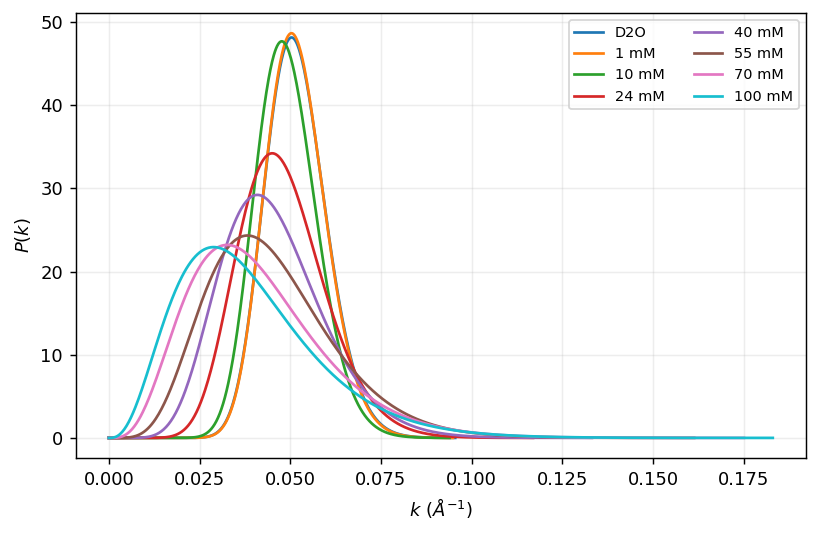

[saved] output\ca_aniso\comparison\gamma_radial_full_geom\ca_k_distribution_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for result, color in zip(results, colors):
    p = result['parameters']
    if K_DISTRIBUTION == 'gamma_radial':
        k, density = cf.gamma_radial_density_from_k_eff(
            p['k_eff'], p['r_sigma_k'],
            upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
        )
    else:
        k, density = cf.gaussian_radial_density_from_k_eff(
            p['k_eff'], p['r_sigma_k'],
            upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
        )
    concentration = result['concentration_mM']
    label = 'D2O' if concentration == 0 else f'{concentration:g} mM'
    ax.plot(k, density, color=color, lw=1.5, label=label)
ax.set(xlabel=r'$k$ ($\AA^{-1}$)', ylabel=r'$P(k)$')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
distribution_figure = COMPARE_OUTPUT_DIR / 'ca_k_distribution_comparison.png'
fig.savefig(distribution_figure, bbox_inches='tight')
plt.show()
print('[saved]', distribution_figure)
